Ogłoszenia nieruchomości są ze stronyKV.ee

**Autor:** Stanisław Kwak · **Licencja:** MIT

Rozkłady zmiennych pod model regresji ceny

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from repozytorium.data.loader import LadowarkaDanych
from repozytorium.data.feature_engineering import BudowniczyCech
from repozytorium.data import schema

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

Matplotlib is building the font cache; this may take a moment.


1. Wczytanie i podstawowe statystyki

In [2]:
df = LadowarkaDanych(ROOT / "kv_clean.sqlite3").wczytaj_do_modelu()
print(f"Liczba ogłoszeń po filtrach: {len(df):,}")
df.describe(include="all").T.head(15)

Liczba ogłoszeń po filtrach: 8,978


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
url,8978,8978,https://www.kv.ee/01-03-2026-a-solmiti-rendin-...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cena,8978.0,NaN,NaN,NaN,190540.636556,157264.498071,10000.0,83900.0,159900.0,251967.5,1700000.0
cena_za_m2,8972.0,NaN,NaN,NaN,3036.388096,1698.866713,8.0,1816.75,3048.0,4051.25,11219.0
liczba_pokoi,8938.0,NaN,NaN,NaN,2.615798,1.006338,1.0,2.0,3.0,3.0,11.0
liczba_sypialni,6375.0,NaN,NaN,NaN,1.816,0.855148,1.0,1.0,2.0,2.0,11.0
powierzchnia_m2,8972.0,NaN,NaN,NaN,61.178165,27.52276,10.2,43.8,56.7,72.725,428.7
pietro,8636.0,NaN,NaN,NaN,4.412228,129.288274,1.0,2.0,2.0,4.0,12016.0
liczba_pieter,8636.0,NaN,NaN,NaN,4.887564,3.322814,1.0,3.0,4.0,5.0,30.0
rok_budowy,8033.0,NaN,NaN,NaN,1992.559318,61.95045,1.0,1973.0,2000.0,2025.0,2028.0
stan,8779,5,Nowy / Deweloperski,3301,NaN,NaN,NaN,NaN,NaN,NaN,NaN


2. Rozkład ceny

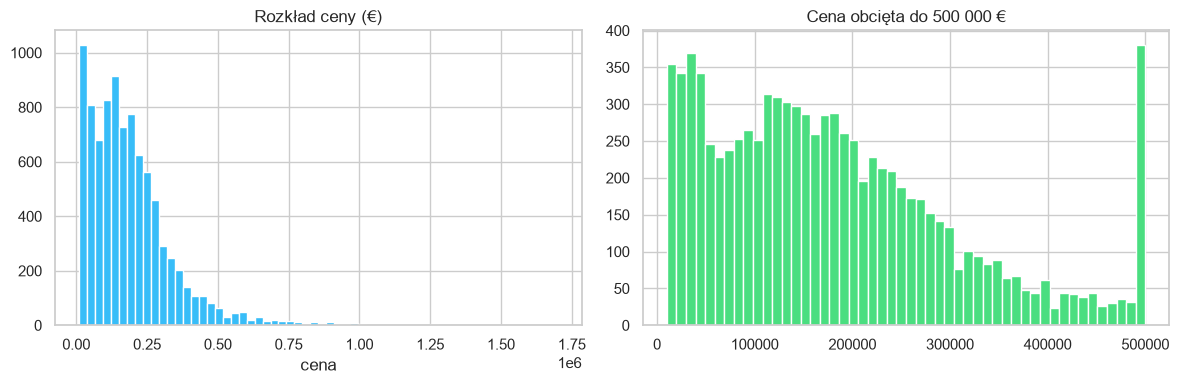

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["cena"], bins=60, color="#38bdf8", edgecolor="white")
axes[0].set_title("Rozkład ceny (€)")
axes[0].set_xlabel("cena")
axes[1].hist(df["cena"].clip(upper=500_000), bins=50, color="#4ade80", edgecolor="white")
axes[1].set_title("Cena obcięta do 500 000 €")
plt.tight_layout()
plt.show()

3. Cechy strukturalne vs cena

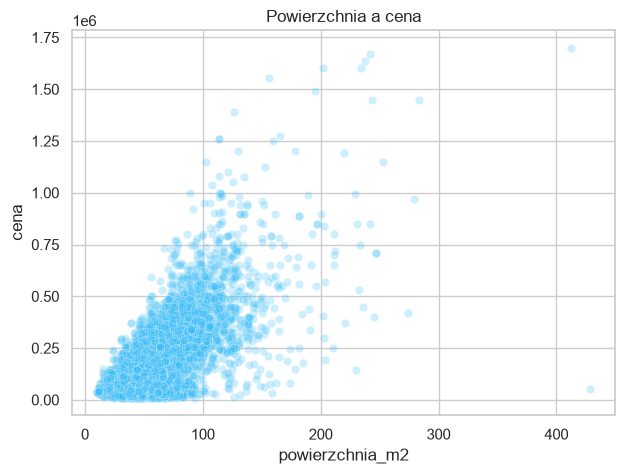

/var/folders/w3/tdsd1ztj74798xj7b063__2c0000gn/T/ipykernel_8776/4009470398.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="stan", y="cena", ax=ax, palette="Set2")


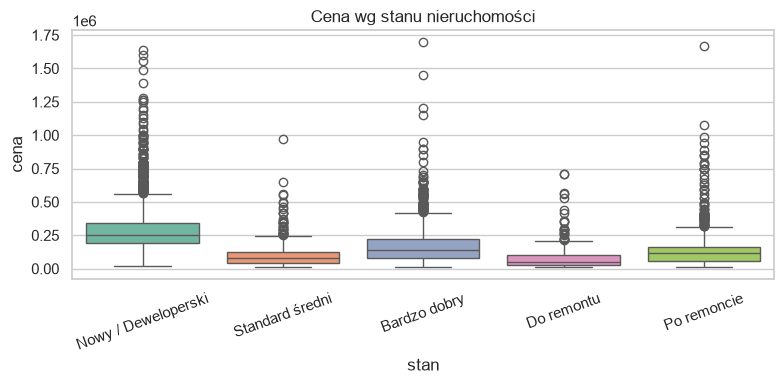

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x="powierzchnia_m2", y="cena", alpha=0.25, ax=ax, color="#38bdf8")
ax.set_title("Powierzchnia a cena")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x="stan", y="cena", ax=ax, palette="Set2")
ax.tick_params(axis="x", rotation=20)
ax.set_title("Cena wg stanu nieruchomości")
plt.tight_layout()
plt.show()

4. Cechy z tekstu ogłoszenia

Z opisu wyciągamy m.in.:
- `nlp_bliskosc_morza` — wykrycie morfemu słów związanych z morzem (`meri`, `rand`, …)
- `nlp_centrum_miasta` — morfemy typu `kesklinn`, `vanalinn`
- długość opisu i liczba słów (w celu sprawdzenia, czy się przyda)

dlugosc_opisu_znaki: średnia=1908.332, udział>0=98.4%
liczba_slow_opisu: średnia=244.342, udział>0=98.4%
nlp_bliskosc_morza: średnia=0.280, udział>0=28.0%
nlp_centrum_miasta: średnia=0.388, udział>0=38.8%


/var/folders/w3/tdsd1ztj74798xj7b063__2c0000gn/T/ipykernel_8776/2553526569.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


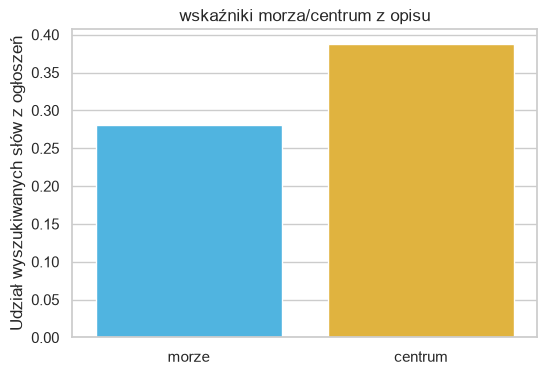

In [5]:
wzb = BudowniczyCech().dodaj_cechy_tekstowe(df)
for col in schema.CECHY_TEKSTOWE:
    print(f"{col}: średnia={wzb[col].mean():.3f}, udział>0={(wzb[col]>0).mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(
    x=["morze", "centrum"],
    y=[wzb["nlp_bliskosc_morza"].mean(), wzb["nlp_centrum_miasta"].mean()],
    palette=["#38bdf8", "#fbbf24"],
    ax=ax,
)
ax.set_ylabel("Udział wyszukiwanych słów z ogłoszeń")
ax.set_title("wskaźniki morza/centrum z opisu")
plt.show()

5. Korelacje

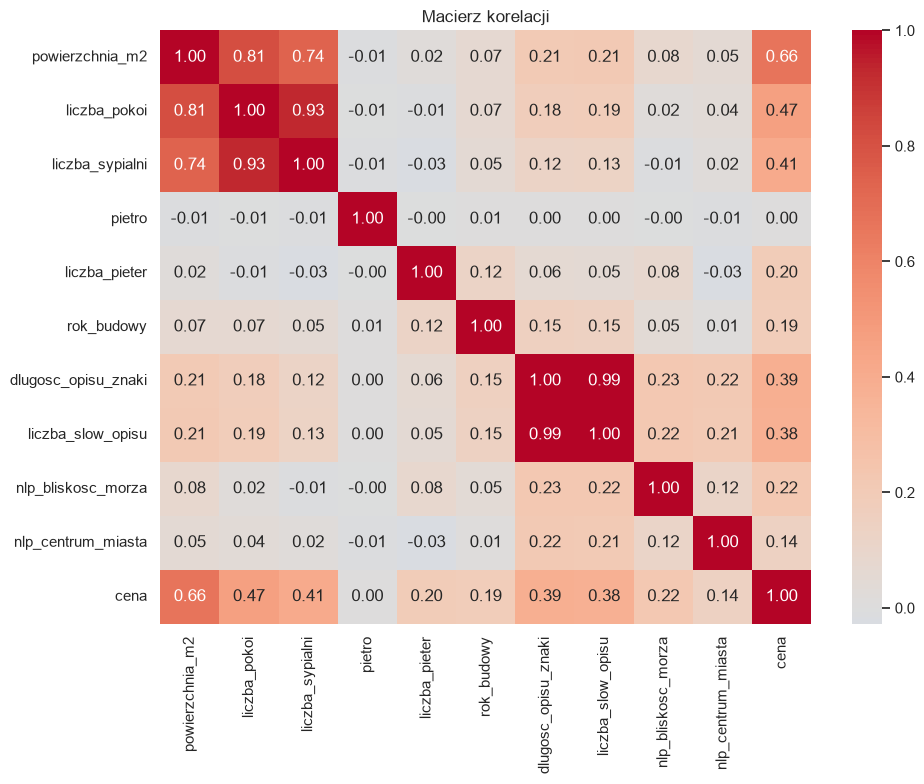

In [6]:
korel = wzb[list(schema.CECHY_NUMERYCZNE_PELNE) + ["cena"]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(korel, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Macierz korelacji")
plt.tight_layout()
plt.show()

6. Podsumowanie pod model

Model trenowany jest w `python -m repozytorium.model.trening` na cechach ze `schema.WSZYSTKIE_CECHY`.